In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy.stats import ttest_rel, ttest_1samp

from utils.configs import REJECT_SID

plt.rc("font", family="Arial")

def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "n.s."


SEED = 1016

### Visualize response time (RT)


========== Run 1 (Practice) ==========
Number of subjects: 34
Sta:       760 ± 153 ms
DevSem:    856 ± 200 ms
DevSynC2:  850 ± 235 ms
DevSynC1:  802 ± 226 ms

Pairwise paired t-tests (two-tailed):
Sta vs DevSem: t(33) = -4.012, p = 0.00032 | Cohen's d = -0.688
Sta vs DevSynC2: t(33) = -3.173, p = 0.00325 | Cohen's d = -0.544
Sta vs DevSynC1: t(33) = -1.622, p = 0.11437 | Cohen's d = -0.278
DevSem vs DevSynC2: t(33) = 0.151, p = 0.88120 | Cohen's d =  0.026
DevSem vs DevSynC1: t(33) = 1.657, p = 0.10691 | Cohen's d =  0.284
DevSynC2 vs DevSynC1: t(33) = 2.327, p = 0.02622 | Cohen's d =  0.399

========== Runs 2-4 (Repetitions) ==========
Number of subjects: 34
Sta:       731 ± 188 ms
DevSem:    803 ± 204 ms
DevSynC2:  729 ± 216 ms
DevSynC1:  689 ± 179 ms

Pairwise paired t-tests (two-tailed):
Sta vs DevSem: t(33) = -4.803, p = 0.00003 | Cohen's d = -0.824
Sta vs DevSynC2: t(33) = 0.141, p = 0.88836 | Cohen's d =  0.024
Sta vs DevSynC1: t(33) = 3.142, p = 0.00353 | Cohen's d =  0.539
De

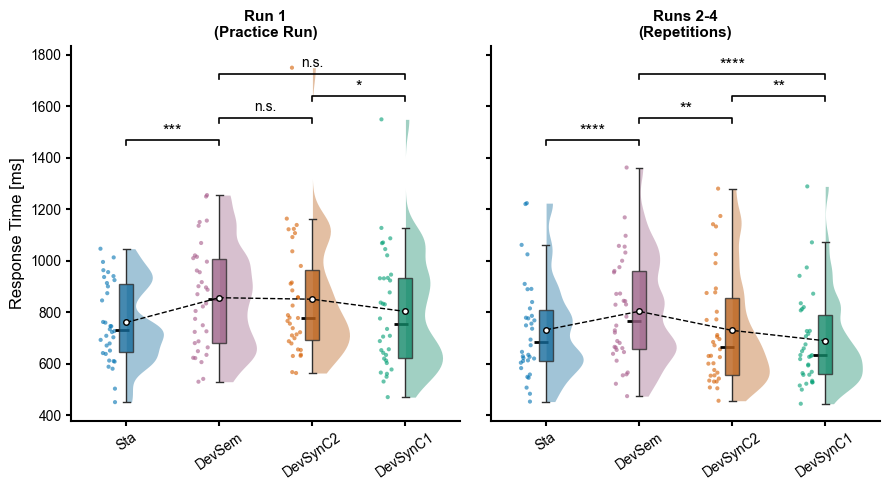

In [2]:
root = "./data/derivatives/behaviors"
max_resp_time = 2.5

labels = ["Sta", "DevSem", "DevSynC2", "DevSynC1"]
colors = ["#0072b2", "#A65A8A", "#d55e00", "#009e73"]

def _process_runs(run_numbers):
    RT = {}

    for run in run_numbers:
        for file in os.listdir(root):
            if not file.endswith(".csv"): continue
            
            if f"run{run}" not in file: continue

            sid = "sub-" + file.split("_")[0].lower()
            if sid in REJECT_SID: continue

            df = pd.read_csv(os.path.join(root, file), encoding="utf-8", sep=",")
            
            stim_fnames = df["Stim_fname"][1:-1].values
            resp_times = df["key_resp.rt"][1:-1].values
            resp_times[np.isnan(resp_times)] = max_resp_time

            if sid not in RT:
                RT[sid] = {"sta": [], "dev1": [], "dev2": [], "dev3": []}

            for fname, rt in zip(stim_fnames, resp_times):
                if np.isnan(rt): continue

                block_type = fname.split("_")[1]
                sent_type = "sta" if ("sent-4" in fname or "sent-1" in fname) else "dev"

                if sent_type == "sta":
                    RT[sid]["sta"].append(rt)
                else:
                    if block_type == "block-1":
                        RT[sid]["dev1"].append(rt)
                    elif block_type == "block-2":
                        RT[sid]["dev2"].append(rt)
                    elif block_type == "block-3":
                        RT[sid]["dev3"].append(rt)

    sid_list, sta_list, dev1_list, dev2_list, dev3_list = [], [], [], [], []
    for sid in sorted(RT.keys()):
        vals = RT[sid]
        sta_mean = np.mean(vals["sta"]) * 1000 if vals["sta"] else np.nan
        dev1_mean = np.mean(vals["dev1"]) * 1000 if vals["dev1"] else np.nan
        dev2_mean = np.mean(vals["dev2"]) * 1000 if vals["dev2"] else np.nan
        dev3_mean = np.mean(vals["dev3"]) * 1000 if vals["dev3"] else np.nan
        if not any(np.isnan([sta_mean, dev1_mean, dev2_mean, dev3_mean])):
            sid_list.append(sid)
            sta_list.append(sta_mean)
            dev1_list.append(dev1_mean)
            dev2_list.append(dev2_mean)
            dev3_list.append(dev3_mean)

    return {
        "sid": np.array(sid_list),
        "sta": np.array(sta_list),
        "dev1": np.array(dev1_list),
        "dev2": np.array(dev2_list),
        "dev3": np.array(dev3_list)
    }


run1_data = _process_runs([1])
main_data = _process_runs([2, 3, 4])

def _calculate_cohen_d_paired(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

def _print_stats(data, title):
    print(f"\n========== {title} ==========")
    n_sub = len(data["sta"])
    print(f"Number of subjects: {n_sub}")
    print(f"Sta:       {np.mean(data["sta"]):.0f} ± {np.std(data["sta"]):.0f} ms")
    print(f"DevSem:    {np.mean(data["dev1"]):.0f} ± {np.std(data["dev1"]):.0f} ms")
    print(f"DevSynC2:  {np.mean(data["dev2"]):.0f} ± {np.std(data["dev2"]):.0f} ms")
    print(f"DevSynC1:  {np.mean(data["dev3"]):.0f} ± {np.std(data["dev3"]):.0f} ms")

    cond_arrays = [data["sta"], data["dev1"], data["dev2"], data["dev3"]]
    cond_names = ["Sta", "DevSem", "DevSynC2", "DevSynC1"]
    n_conds = len(cond_arrays)
    print("\nPairwise paired t-tests (two-tailed):")
    for i in range(n_conds):
        for j in range(i + 1, n_conds):
            t_stat, p_val = ttest_rel(cond_arrays[i], cond_arrays[j])
            d = _calculate_cohen_d_paired(cond_arrays[i], cond_arrays[j])
            print(f"{cond_names[i]} vs {cond_names[j]}: t({len(cond_arrays[i])-1}) = {t_stat:.3f}, p = {p_val:.5f} | Cohen's d = {d:6.3f}")

_print_stats(run1_data, "Run 1 (Practice)")
_print_stats(main_data, "Runs 2-4 (Repetitions)")

def _prepare_df(data_dict):
    df_list = []
    key_map = {"sta": "Sta", "dev1": "DevSem", "dev2": "DevSynC2", "dev3": "DevSynC1"}
    for key, label in key_map.items():
        temp_df = pd.DataFrame({
            "RT": data_dict[key],
            "Condition": label
        })
        df_list.append(temp_df)
    return pd.concat(df_list, ignore_index=True)

df_run1 = _prepare_df(run1_data)
df_main = _prepare_df(main_data)

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

all_dfs = [df_run1, df_main]
all_datasets = [run1_data, main_data]
titles = ["Run 1\n(Practice Run)", "Runs 2-4\n(Repetitions)"]

global_y_max = 1400
global_y_min = min(df_run1["RT"].min(), df_main["RT"].min())
y_range = global_y_max - global_y_min
bracket_height = y_range * 0.02
bracket_step = y_range * 0.09

for ax, df, raw_data, title in zip(axes, all_dfs, all_datasets, titles):
    
    for i, label in enumerate(labels):
        sns.violinplot(data=df[df["Condition"] == label], x="Condition", y="RT", 
                       hue="Condition", ax=ax, palette=[colors[i]], bw_adjust=.5, cut=0, 
                       inner=None, linewidth=0, alpha=0.4, legend=False)
        
    for poly in ax.collections:
        if "PolyCollection" in str(type(poly)):
            paths = poly.get_paths()
            for path in paths:
                m = path.vertices[:, 0].mean()
                path.vertices[:, 0] = np.clip(path.vertices[:, 0], m, np.inf)

    sns.stripplot(data=df, x="Condition", y="RT", hue="Condition", palette=colors, 
                  size=3, jitter=0.08, alpha=0.6, zorder=1, ax=ax, legend=False)
    
    for collection in ax.collections[len(labels):]: 
        if "PathCollection" in str(type(collection)):
            offsets = collection.get_offsets()
            offsets[:, 0] = offsets[:, 0] - 0.2
            collection.set_offsets(offsets)

    sns.boxplot(data=df, x="Condition", y="RT", hue="Condition", palette=colors,
                width=0.15, showcaps=True, showfliers=False, 
                boxprops={"zorder": 10, "alpha": 0.8},
                whiskerprops={"zorder": 10},
                medianprops={"color": "black", "linewidth": 2},
                ax=ax, legend=False)
    
    for artist in ax.get_children():
        if "Rectangle" in str(type(artist)):
            artist.set_x(artist.get_x() - 0.05)
        elif "Line2D" in str(type(artist)):
            if artist.get_zorder() < 20 and artist.get_linewidth() != 1: 
                artist.set_xdata(artist.get_xdata() - 0.05)

    means = [df[df["Condition"] == l]["RT"].mean() for l in labels]
    ax.plot([0, 1, 2, 3], means, color="black", linestyle="--", linewidth=1, 
            marker="o", markersize=4, markerfacecolor="white", zorder=20)

    data_arrays = [raw_data["sta"], raw_data["dev1"], raw_data["dev2"], raw_data["dev3"]]
    
    comparisons = [(0, 1), (1, 2), (2, 3), (1, 3)] 
    # comparisons = [
    #     (0, 1), (1, 2), (2, 3),  
    #     (0, 2), (1, 3),          
    #     (0, 3)                  
    # ] 
    
    current_y = global_y_max + y_range * 0.05
    
    for (i, j) in comparisons:
        stat, pval = ttest_rel(data_arrays[i], data_arrays[j])
        sig_text = convert_pvalue_to_asterisks(pval)
        
        ax.plot([i, i, j, j], [current_y, current_y + bracket_height, current_y + bracket_height, current_y], 
                lw=1.2, color="black")
        
        text_offset = bracket_height * 0.2 if sig_text != "n.s." else bracket_height * 0.8
        font_size = 12 if sig_text != "n.s." else 10
        
        ax.text((i + j) / 2, current_y + bracket_height + text_offset, sig_text, 
                ha="center", va="bottom", color="black", fontsize=font_size)
        
        current_y += bracket_step

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="center")
    ax.tick_params(axis="both", labelsize=10, width=1.5)

axes[0].set_ylim(top=current_y + bracket_step * 0.5)

axes[0].set_ylabel("Response Time [ms]", fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
def print_cross_run_stats(run1, main_data):
    print("\n========== Cross-Run Comparison (Run 1 vs Runs 2-4) ==========")
    
    n_run1 = len(run1["sta"])
    n_main = len(main_data["sta"])
    if n_run1 != n_main:
        print(f"Warning: 被试数量不一致 (Run 1: {n_run1}, Runs 2-4: {n_main})。无法直接执行配对 T 检验！")
        return

    run1_overall = (run1["sta"] + run1["dev1"] + run1["dev2"] + run1["dev3"]) / 4
    main_overall = (main_data["sta"] + main_data["dev1"] + main_data["dev2"] + main_data["dev3"]) / 4

    t_stat, p_val = ttest_rel(run1_overall, main_overall)
    d = _calculate_cohen_d_paired(run1_overall, main_overall)
    sig = convert_pvalue_to_asterisks(p_val)

    print("--- Overall RT (All Conditions Averaged) ---")
    print(f"Run 1 Average:    {np.mean(run1_overall):.0f} ± {np.std(run1_overall):.0f} ms")
    print(f"Runs 2-4 Average: {np.mean(main_overall):.0f} ± {np.std(main_overall):.0f} ms")
    print(f"Overall Test:     t({n_run1 - 1}) = {t_stat:6.3f}, p = {p_val:7.5f} {sig:4s} | Cohen's d = {d:6.3f}\n")

    print("--- Condition-wise Comparison (Run 1 vs Runs 2-4) ---")
    cond_map = {
        "sta": "Sta", 
        "dev1": "DevSem", 
        "dev2": "DevSynC2", 
        "dev3": "DevSynC1"
    }
    
    for key, name in cond_map.items():
        t_stat_c, p_val_c = ttest_rel(run1[key], main_data[key])
        d_c = _calculate_cohen_d_paired(run1[key], main_data[key])
        sig_c = convert_pvalue_to_asterisks(p_val_c)
        print(f"{name:8s}: t({n_run1 - 1}) = {t_stat_c:6.3f}, p = {p_val_c:7.5f} {sig_c:4s} | Cohen's d = {d_c:6.3f}")

print_cross_run_stats(run1_data, main_data)


========== Cross-Run Comparison (Run 1 vs Runs 2-4) ==========
--- Overall RT (All Conditions Averaged) ---
Run 1 Average:    817 ± 179 ms
Runs 2-4 Average: 738 ± 189 ms
Overall Test:     t(33) =  2.914, p = 0.00636 **   | Cohen's d =  0.500

--- Condition-wise Comparison (Run 1 vs Runs 2-4) ---
Sta     : t(33) =  1.216, p = 0.23278 n.s. | Cohen's d =  0.208
DevSem  : t(33) =  1.876, p = 0.06953 n.s. | Cohen's d =  0.322
DevSynC2: t(33) =  3.038, p = 0.00463 **   | Cohen's d =  0.521
DevSynC1: t(33) =  3.156, p = 0.00341 **   | Cohen's d =  0.541


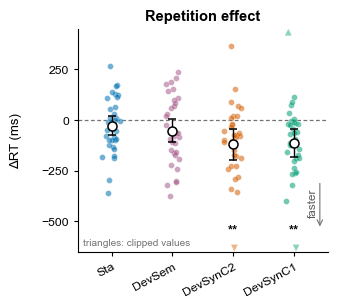

In [8]:
# Within-subject RT change from Run 1 to Runs 2-4:
#     ΔRT = RT(Runs 2-4) - RT(Run 1)
# Negative values mean that responses became faster after repetition.

def _mean_ci95(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    mean = np.mean(x)
    ci95 = 1.96 * np.std(x, ddof=1) / np.sqrt(len(x))
    return mean, ci95


def _align_run_data(run1, main):
    
    sids = sorted(set(run1["sid"]).intersection(set(main["sid"])))

    run1_index = {sid: idx for idx, sid in enumerate(run1["sid"])}
    main_index = {sid: idx for idx, sid in enumerate(main["sid"])}

    aligned = {"sid": np.array(sids)}
    for key in ["sta", "dev1", "dev2", "dev3"]:
        aligned[f"run1_{key}"] = np.array([run1[key][run1_index[sid]] for sid in sids])
        aligned[f"main_{key}"] = np.array([main[key][main_index[sid]] for sid in sids])
        aligned[f"delta_{key}"] = aligned[f"main_{key}"] - aligned[f"run1_{key}"]
    return aligned


def _prepare_delta_df(run1, main):
    
    aligned = _align_run_data(run1, main)
    key_map = {
        "sta": "Sta",
        "dev1": "DevSem",
        "dev2": "DevSynC2",
        "dev3": "DevSynC1"
    }

    rows = []
    for sid in aligned["sid"]:
        sid_idx = np.where(aligned["sid"] == sid)[0][0]
        for key, label in key_map.items():
            rows.append({
                "sid": sid,
                "Condition": label,
                "delta_RT": aligned[f"delta_{key}"][sid_idx],
                "run1_RT": aligned[f"run1_{key}"][sid_idx],
                "runs2_4_RT": aligned[f"main_{key}"][sid_idx]
            })
    return pd.DataFrame(rows)


def plot_speeding(
    run1,
    main,
    show=True,
    y_limits=(-650, 450),
):
    
    delta_df = _prepare_delta_df(run1, main)

    plot_labels = ["Sta", "DevSem", "DevSynC2", "DevSynC1"]
    x_positions = np.arange(len(labels))

    fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.1))
    rng = np.random.default_rng(SEED)

    ymin, ymax = y_limits

    ax.axhline(0, color="0.45", lw=0.9, ls=(0, (3, 2)), zorder=0)

    summary_rows = []
    for i, label in enumerate(labels):
        vals = delta_df.loc[delta_df["Condition"] == label, "delta_RT"].values
        mean, ci95 = _mean_ci95(vals)
        summary_rows.append((label, mean, ci95))

        # Split regular and clipped points. Keep all values for summary statistics.
        lower_mask = vals < ymin
        upper_mask = vals > ymax
        inside_mask = ~(lower_mask | upper_mask)

        jitter_inside = rng.normal(loc=0.0, scale=0.065, size=inside_mask.sum())
        ax.scatter(
            np.full(inside_mask.sum(), x_positions[i], dtype=float) + jitter_inside,
            vals[inside_mask],
            s=18,
            color=colors[i],
            alpha=0.55,
            edgecolor="white",
            linewidth=0.25,
            zorder=2,
        )

        # Clipped low outliers: downward triangles on the lower boundary.
        if lower_mask.any():
            jitter_low = rng.normal(loc=0.0, scale=0.065, size=lower_mask.sum())
            ax.scatter(
                np.full(lower_mask.sum(), x_positions[i], dtype=float) + jitter_low,
                np.full(lower_mask.sum(), ymin + 18),
                marker="v",
                s=24,
                color=colors[i],
                alpha=0.45,
                edgecolor="none",
                zorder=2,
            )

        # Clipped high outliers: upward triangles on the upper boundary.
        if upper_mask.any():
            jitter_high = rng.normal(loc=0.0, scale=0.065, size=upper_mask.sum())
            ax.scatter(
                np.full(upper_mask.sum(), x_positions[i], dtype=float) + jitter_high,
                np.full(upper_mask.sum(), ymax - 18),
                marker="^",
                s=24,
                color=colors[i],
                alpha=0.45,
                edgecolor="none",
                zorder=2,
            )

        ax.errorbar(
            x_positions[i],
            mean,
            yerr=ci95,
            fmt="o",
            markersize=6.5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.1,
            ecolor="black",
            elinewidth=1.0,
            capsize=3.0,
            capthick=1.0,
            zorder=5,
        )

        _, p_val = ttest_1samp(vals, popmean=0.0)
        sig = convert_pvalue_to_asterisks(p_val)
        if sig != "n.s.":
            ax.text(
                x_positions[i],
                ymin + 78,
                sig,
                ha="center",
                va="bottom",
                fontsize=9.5,
                fontweight="bold",
                color="black",
            )

    ax.text(
        3.3,
        -410,
        "faster",
        ha="center",
        va="center",
        fontsize=8.5,
        color="0.35",
        rotation=90,
    )
    ax.annotate(
        "",
        xy=(3.42, -540),
        xytext=(3.42, -300),
        arrowprops=dict(arrowstyle="->", color="0.45", lw=0.8),
    )
    
    ax.set_xlim(-0.55, len(labels) - 0.45)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_labels, rotation=28, ha="right", rotation_mode="anchor")
    ax.set_yticks([-500, -250, 0, 250])
    ax.set_ylabel("ΔRT (ms)\n", fontsize=9.5)
    ax.set_xlabel("")
    ax.set_title("Repetition effect", fontsize=10.5, fontweight="bold", pad=6)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["left"].set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=8.8, width=0.8, length=3)

    has_clipped = ((delta_df["delta_RT"] < ymin) | (delta_df["delta_RT"] > ymax)).any()
    if has_clipped:
        ax.text(
            0.02,
            0.02,
            "triangles: clipped values",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7.2,
            color="0.45",
        )

    plt.tight_layout(pad=0.8)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax, delta_df


fig, ax, df = plot_speeding(run1_data, main_data)